<a href="https://colab.research.google.com/github/abdheshdash8/Causal-Inference-for-health-and-nutrition-studies-NFHS-5/blob/main/mtp_nfhs_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded NFHS-5 key indicators file
file_path = "/content/drive/MyDrive/Colab Notebooks/NFHS-5/NFHS5_key_indicators.xlsx"
df = pd.read_excel(file_path)




Mounted at /content/drive


In [ ]:
import numpy as np
import seaborn as sns

# Drop completely empty columns
df = df.dropna(axis=1, how='all')

# Select only numeric columns (key indicators)
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(f"Total numeric indicators found: {len(numeric_cols)}")

Total numeric indicators found: 28


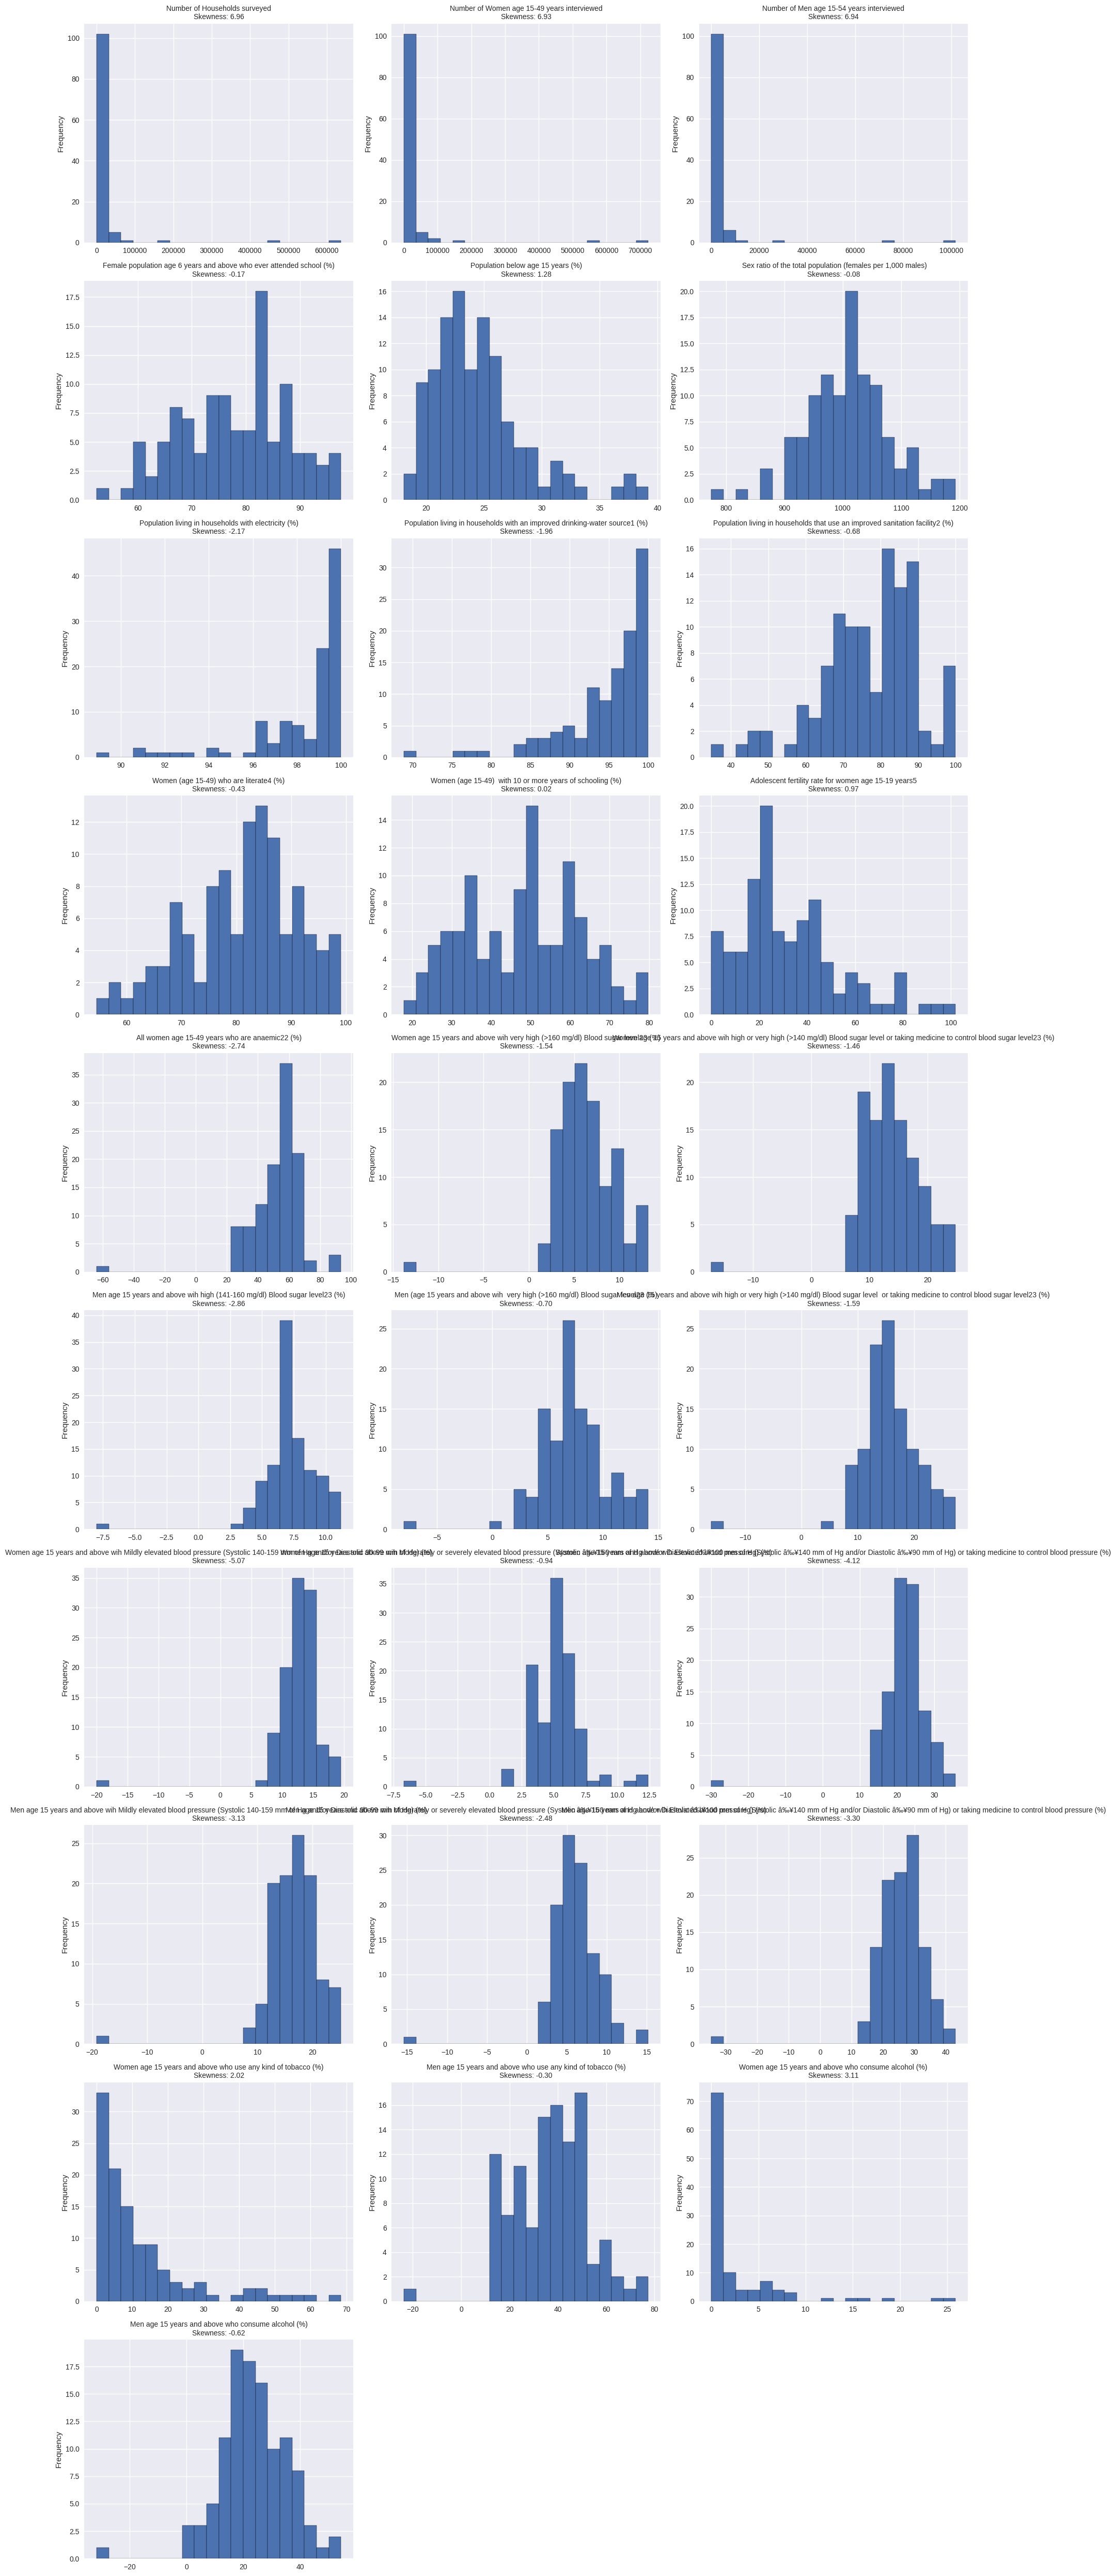

In [ ]:
# Set plot style
plt.style.use('seaborn-v0_8')

# Number of plots
n_cols = 3  # number of columns in grid
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()

    skewness = data.skew()

    axes[i].hist(data, bins=20, edgecolor='black')
    axes[i].set_title(f"{col}\nSkewness: {skewness:.2f}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Basic info of processed data:
<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 3 to 109
Data columns (total 33 columns):
 #   Column                                                                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                                                                --------------  -----  
 0   States/UTs                                                                                                                                                            72 non-null     object 
 1   Area                                                                                                                                                                  72 non-null     object 
 2   Population below age 15 years (%)                                                     

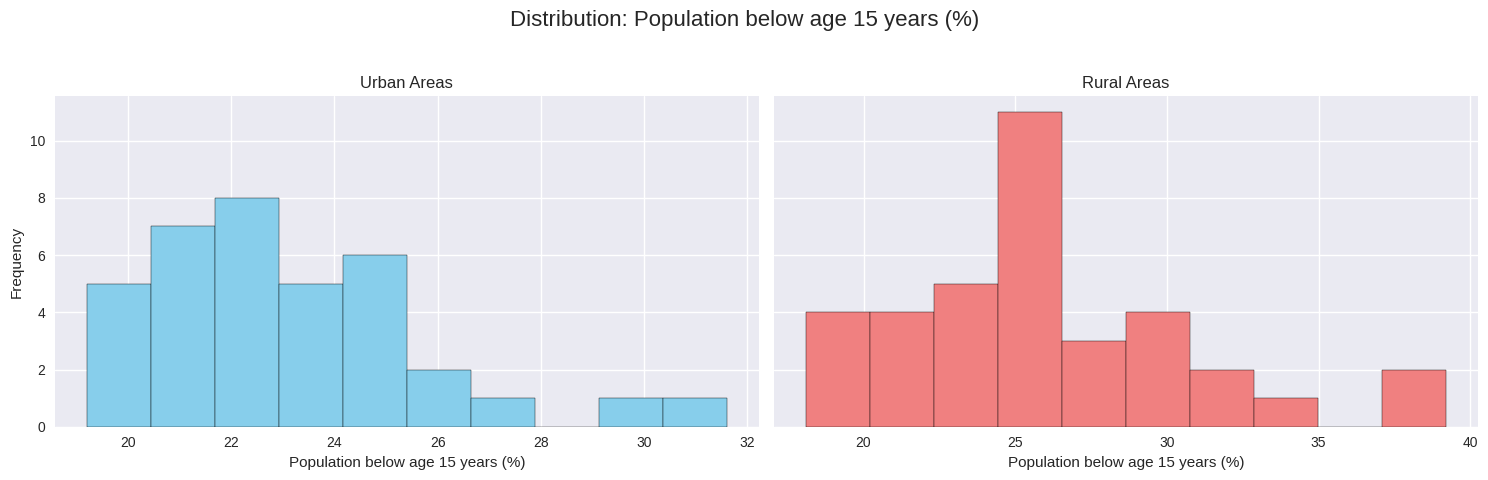

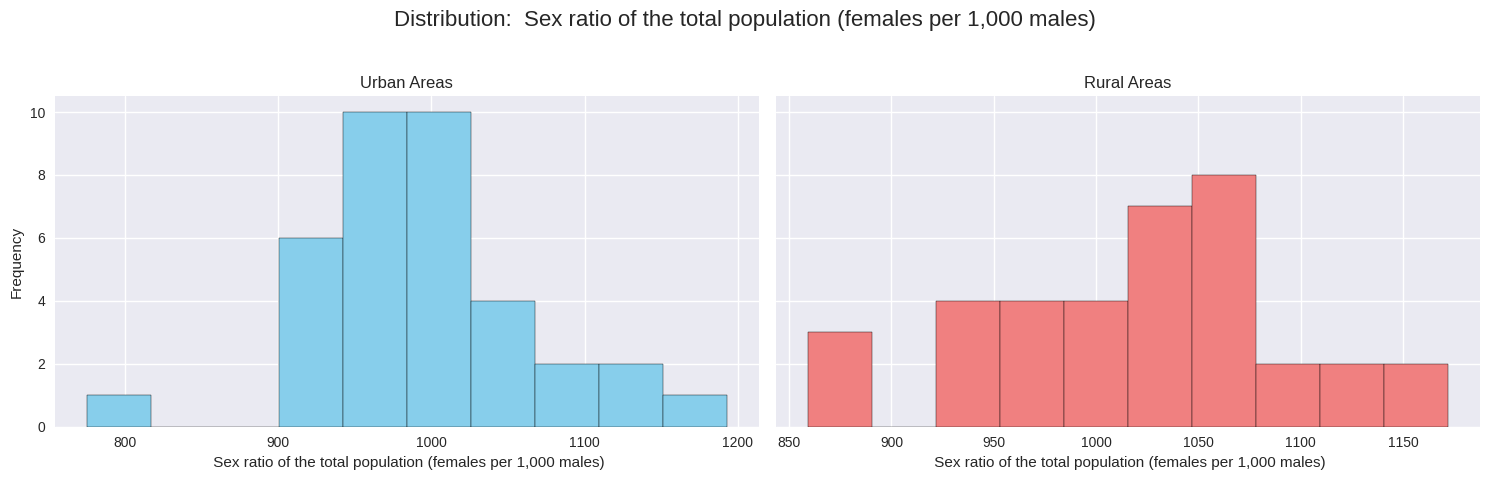

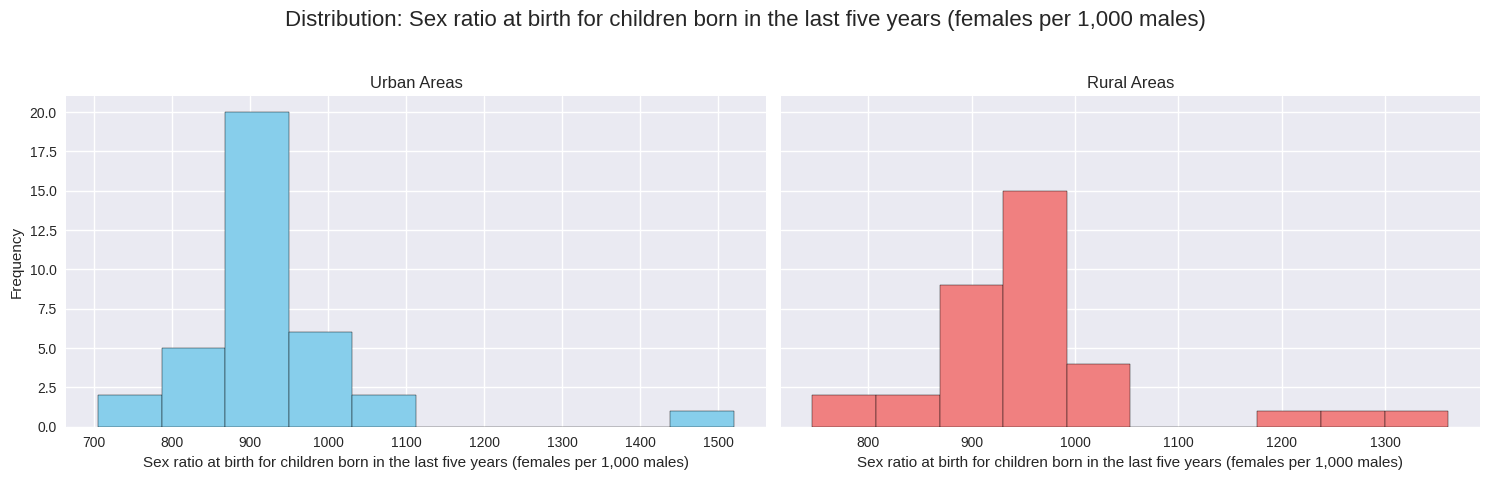

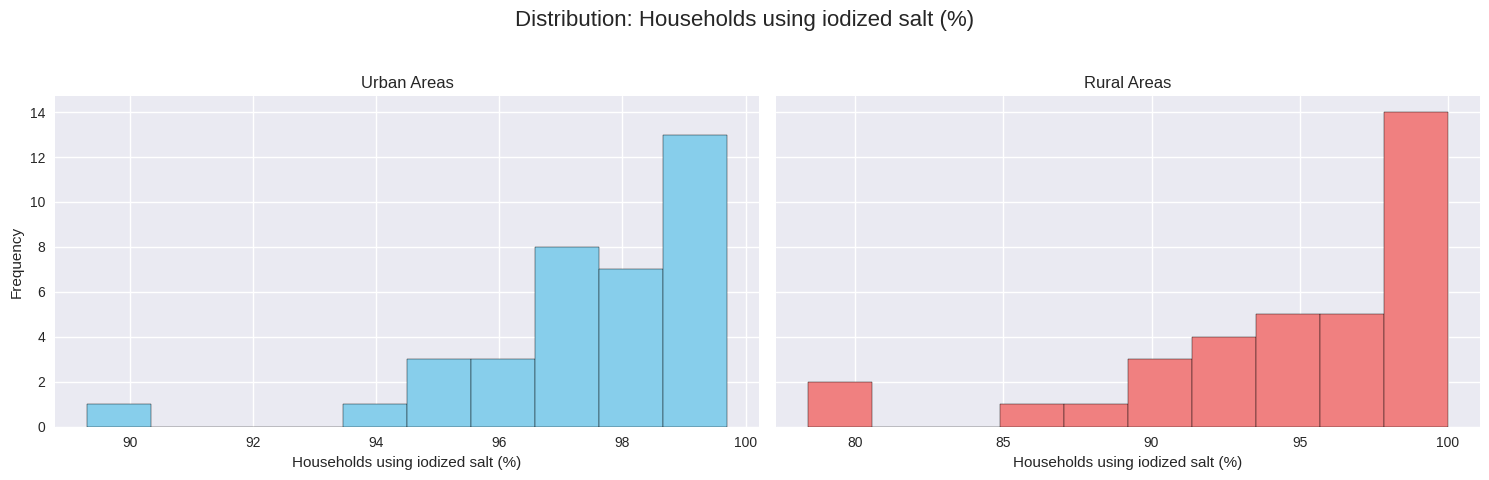

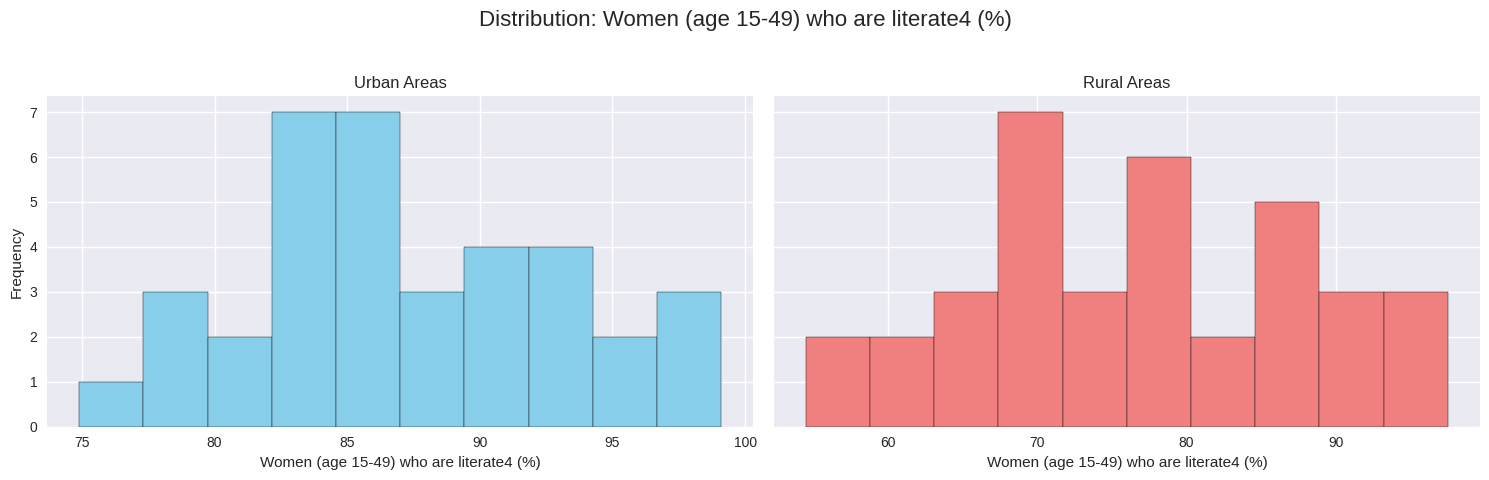

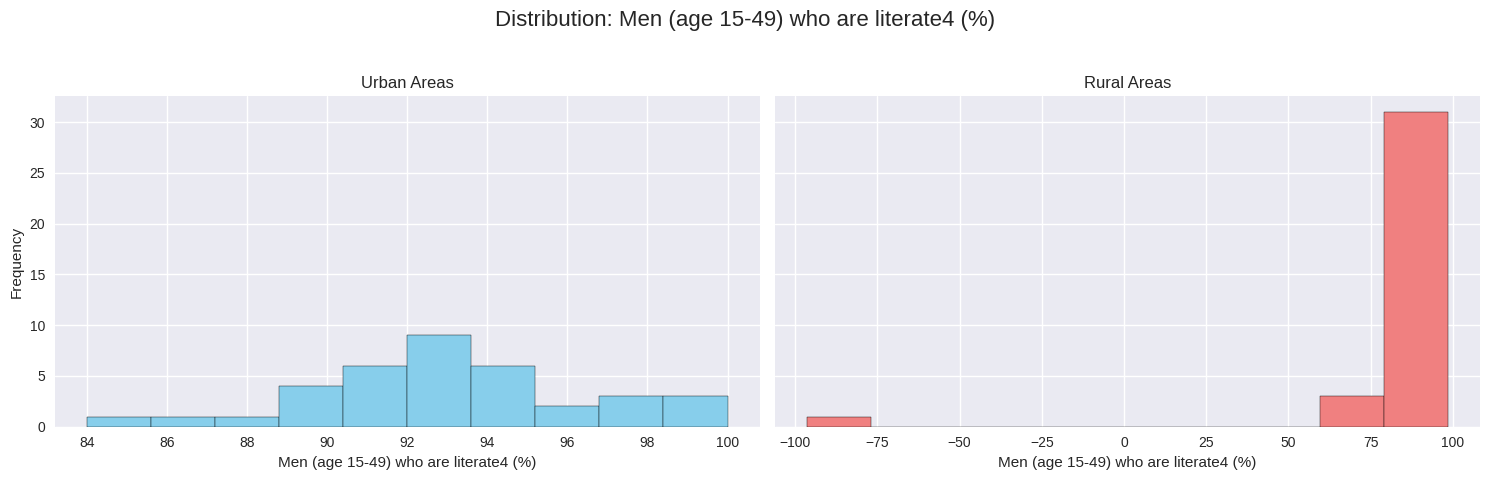

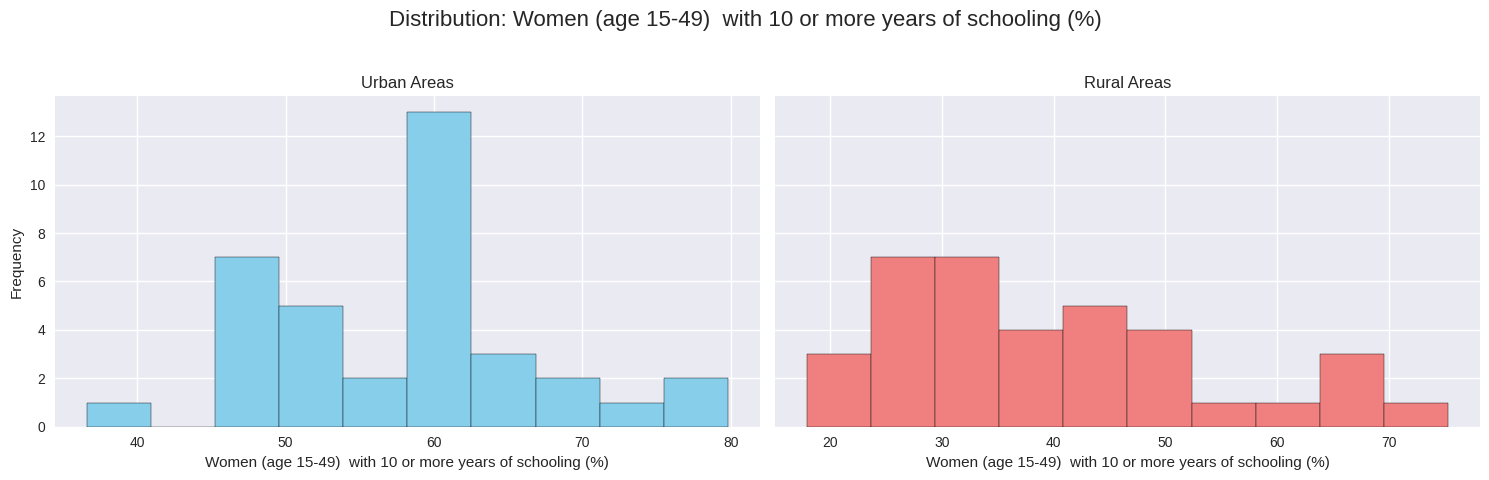

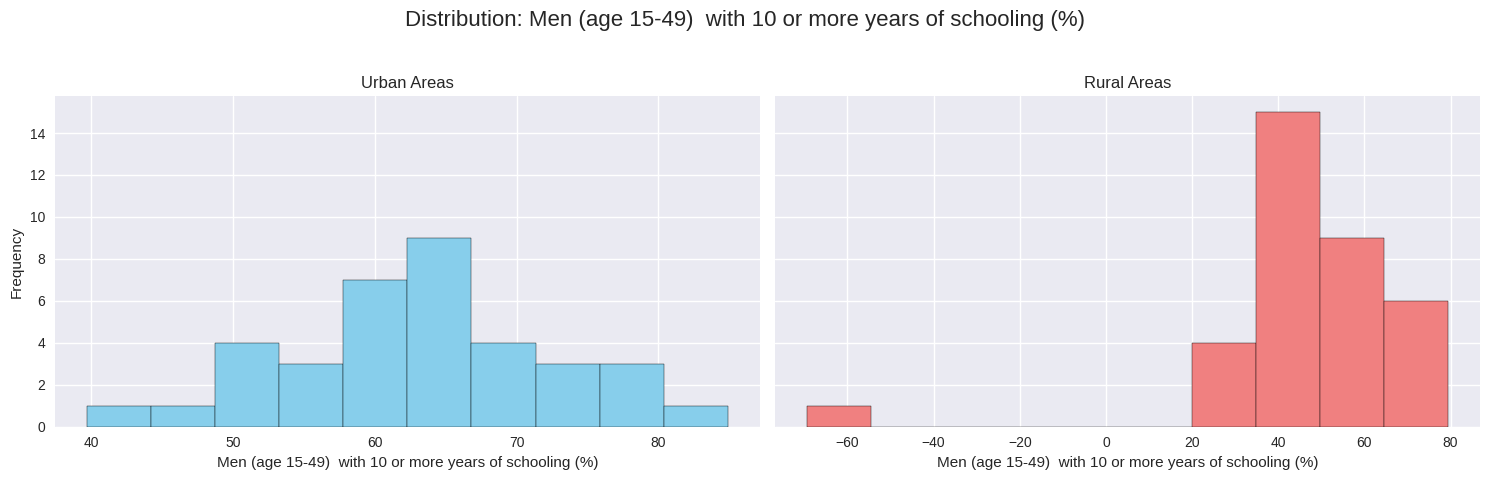

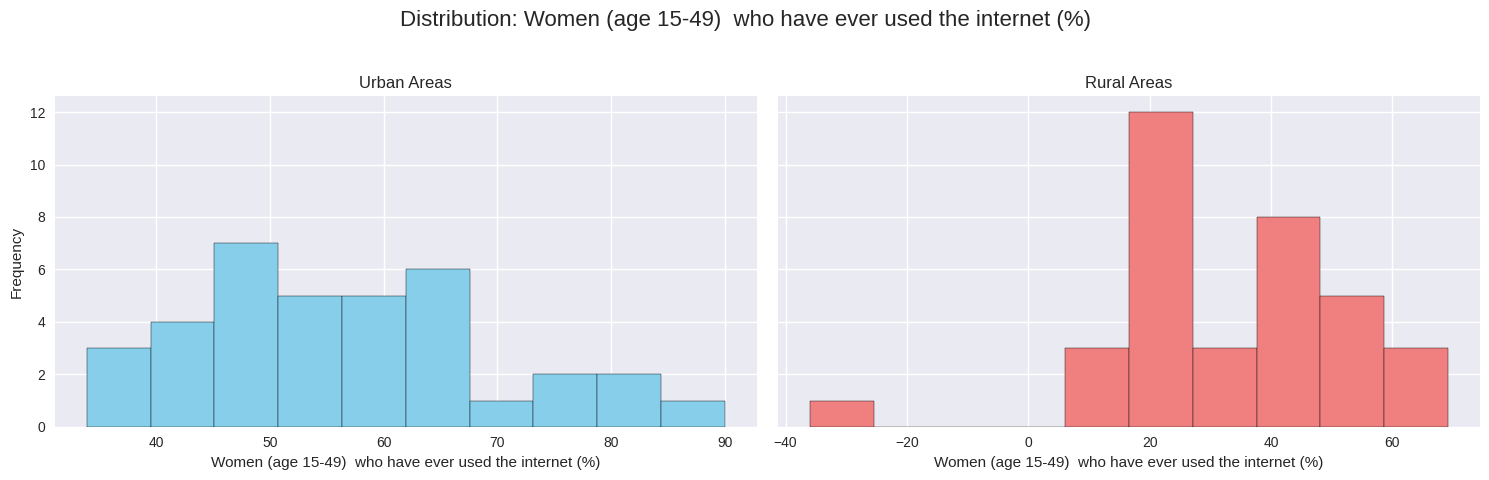

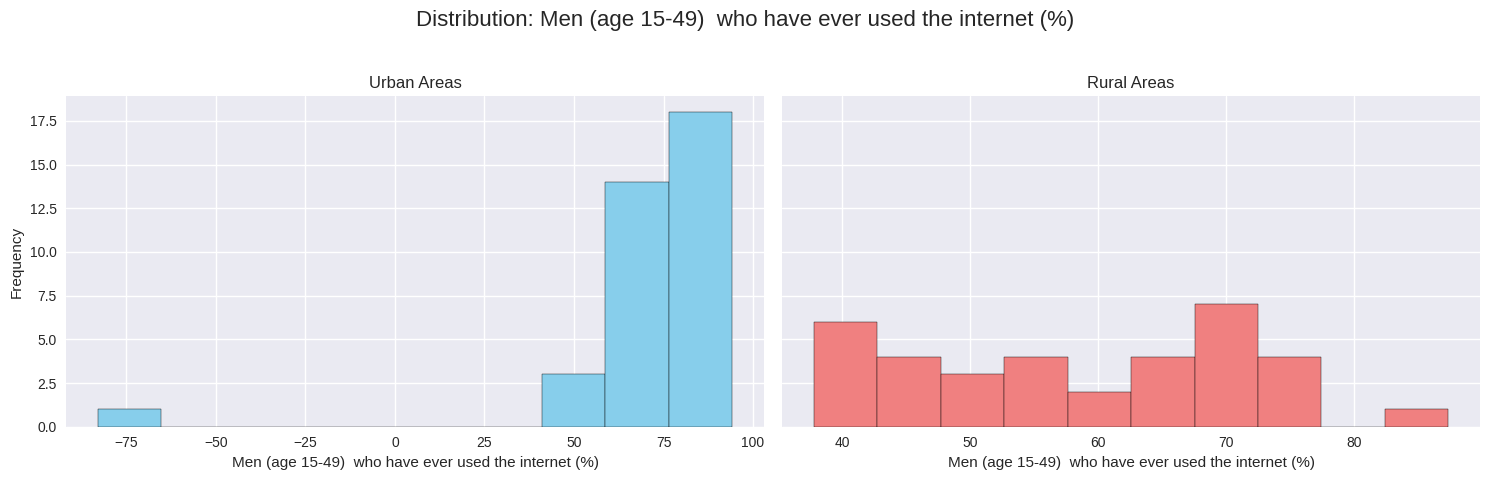

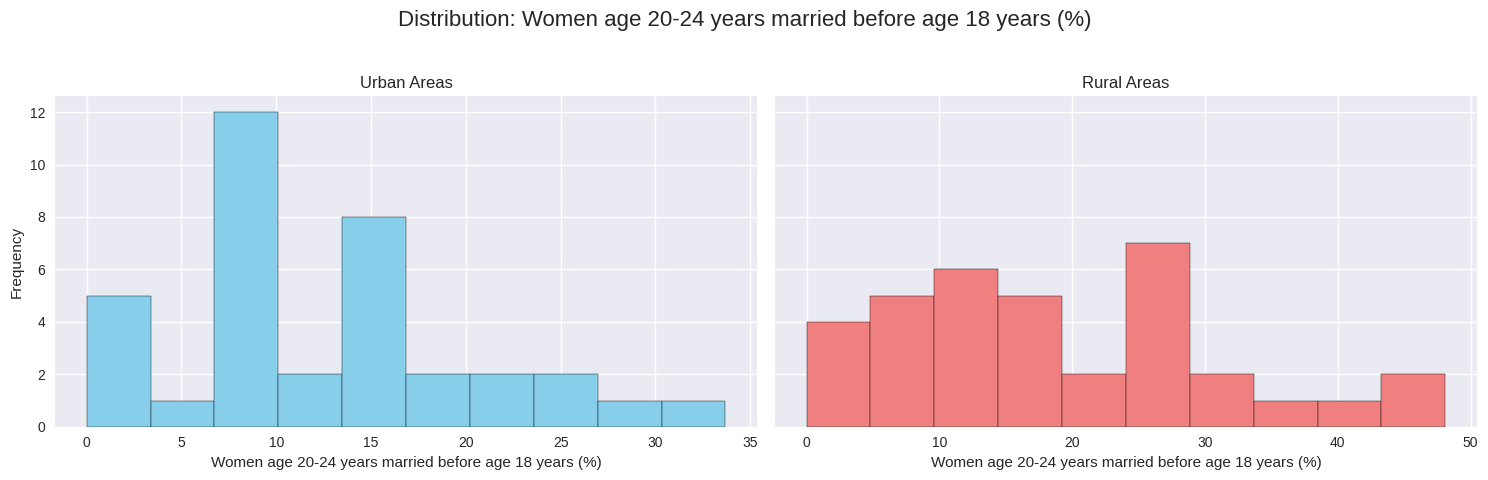

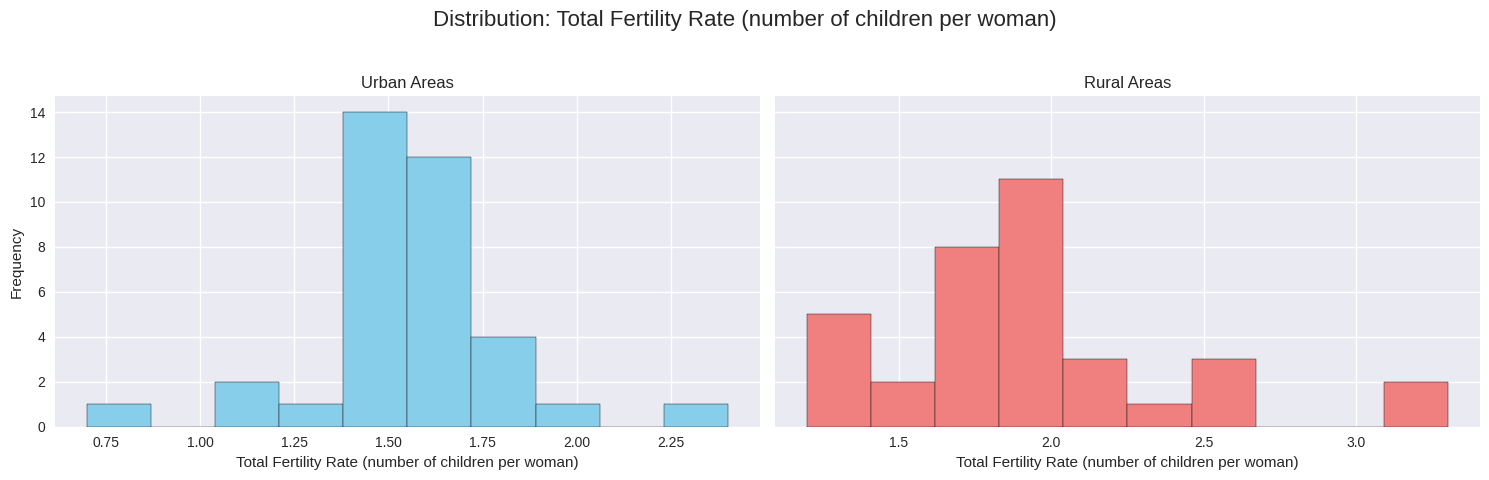

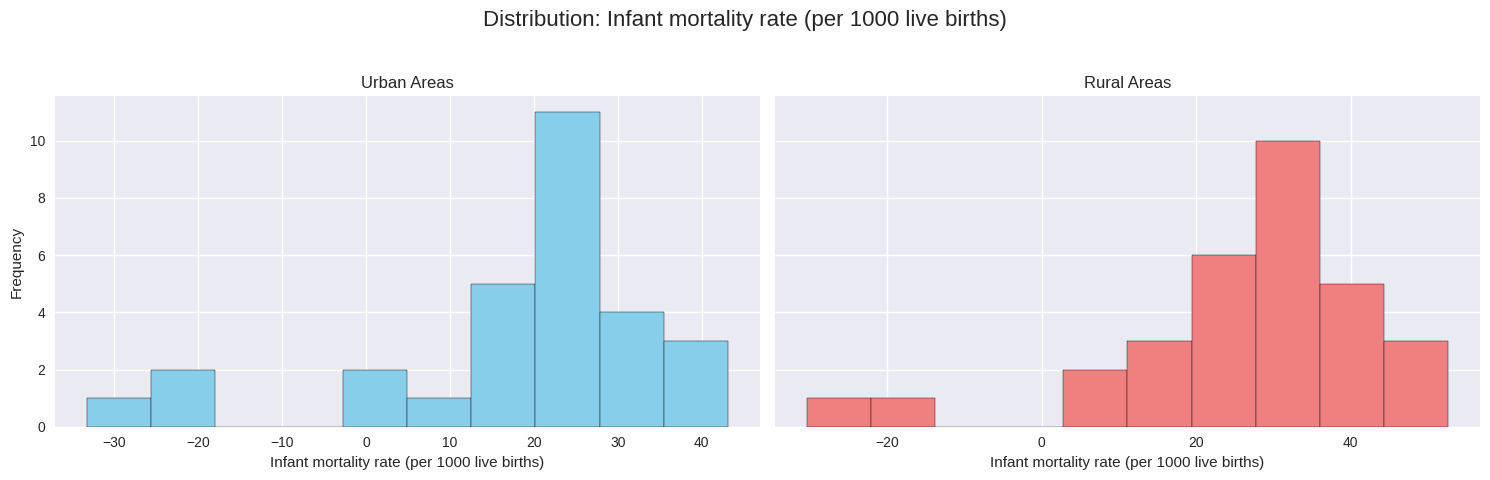

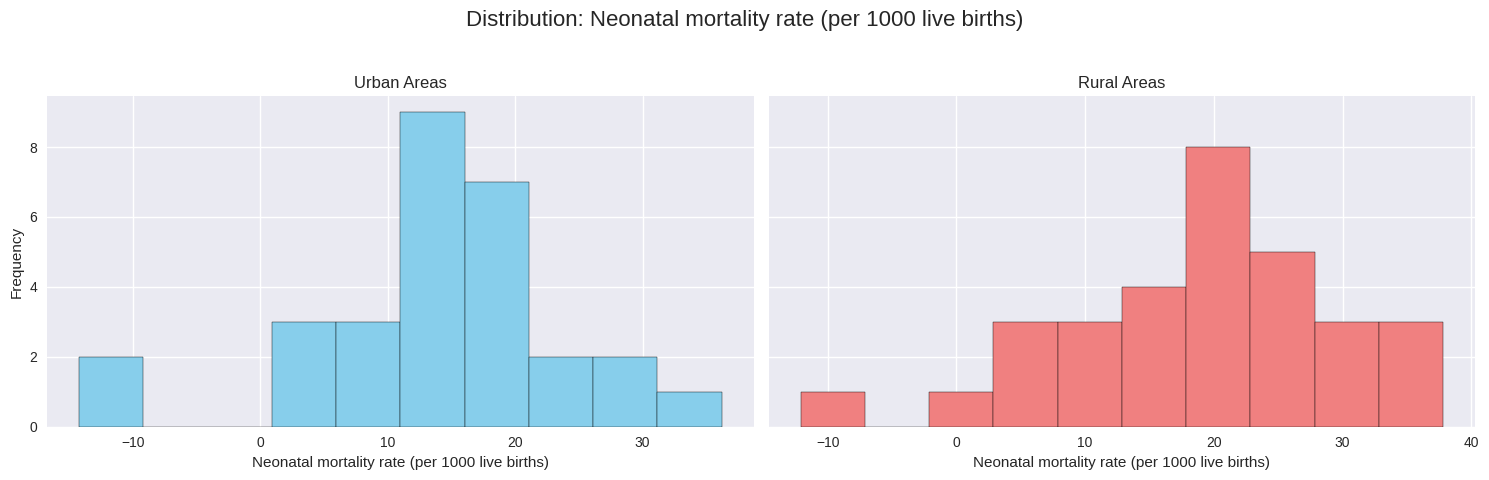

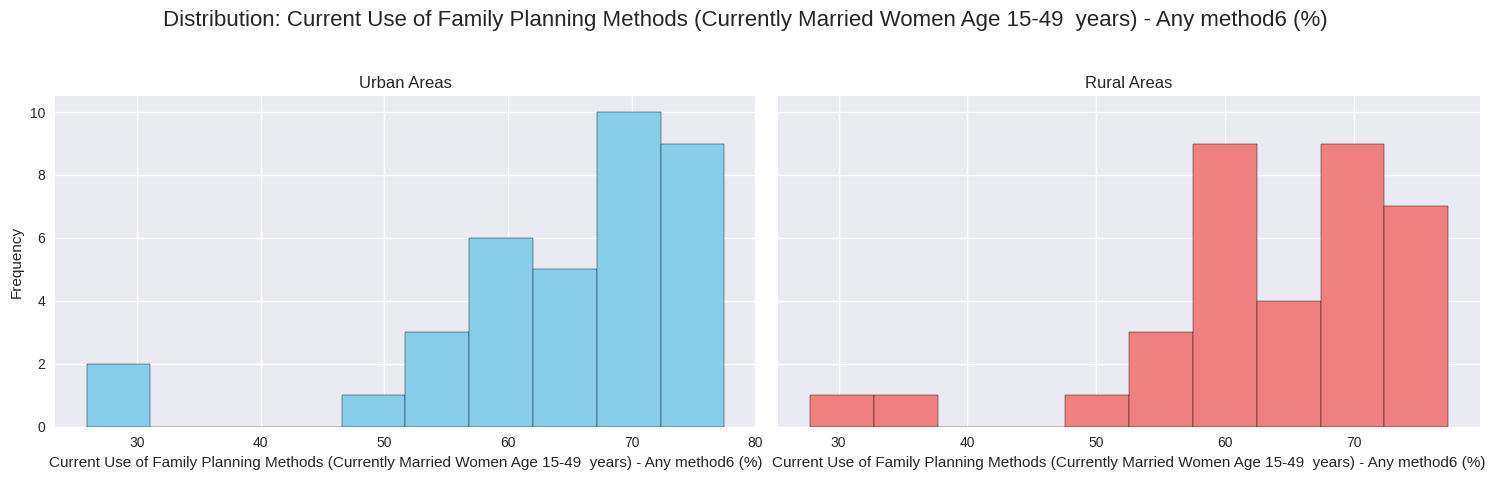

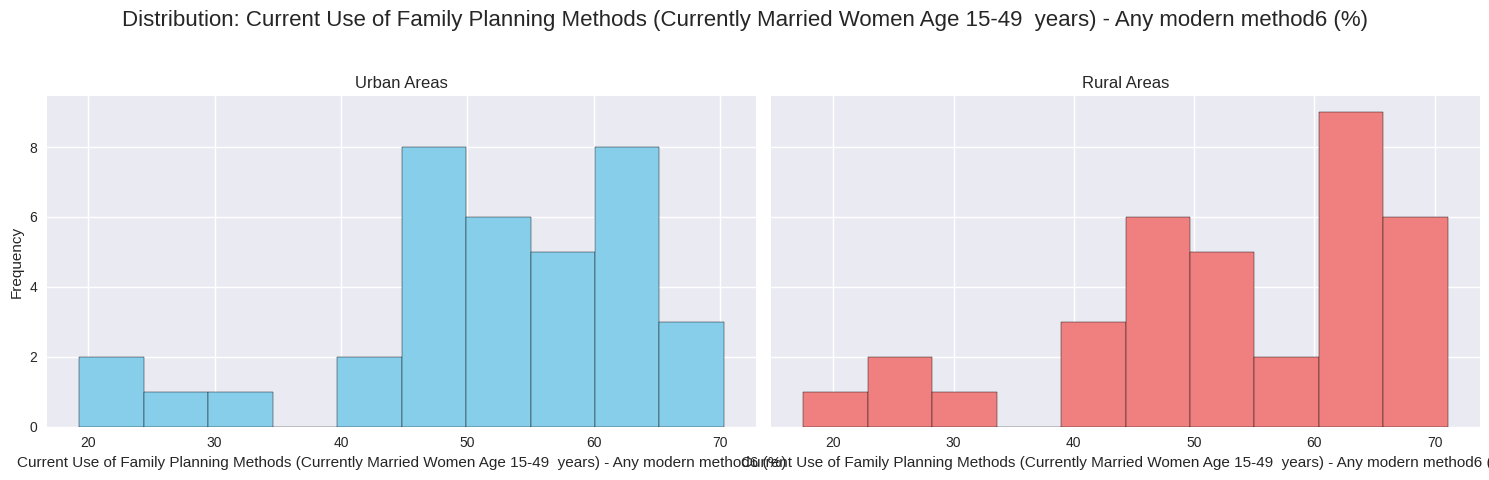

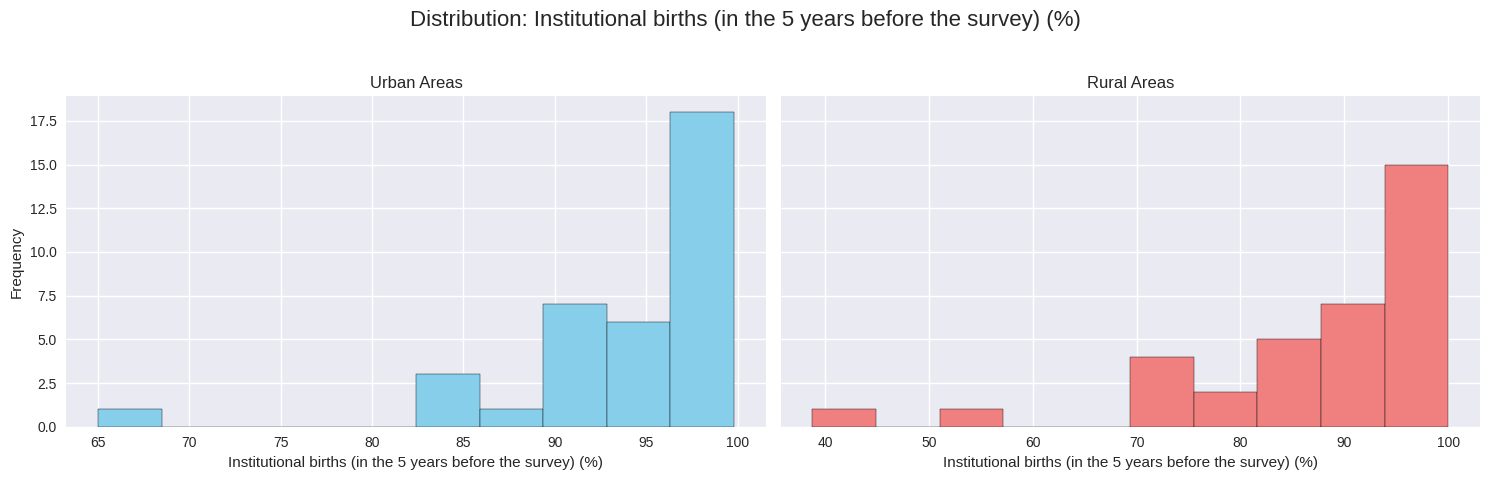

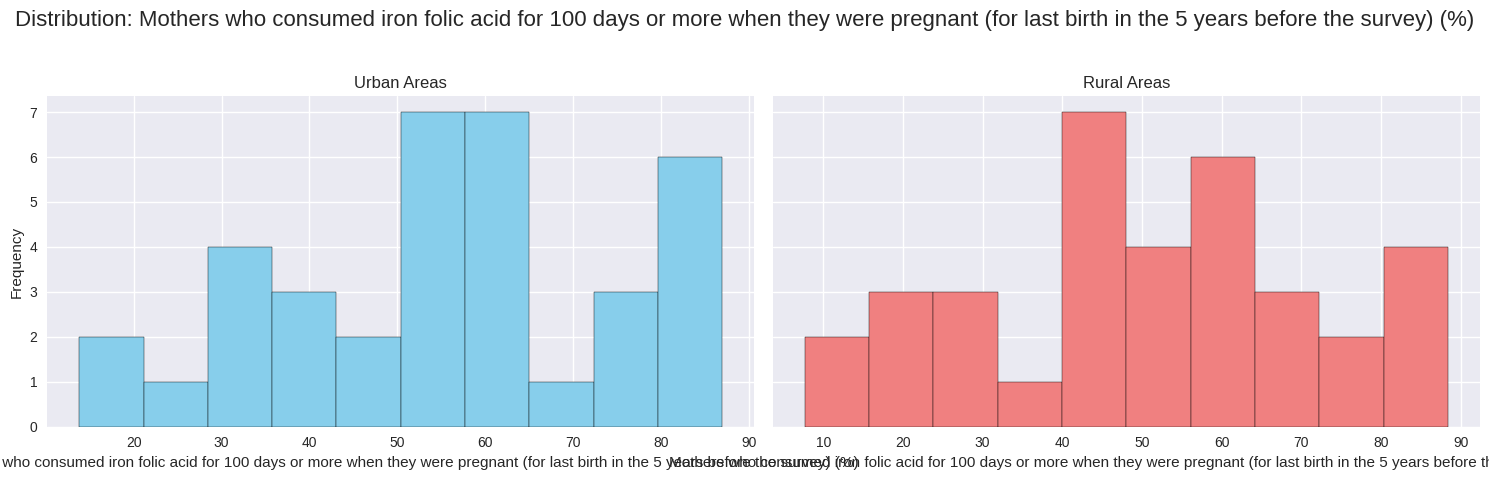

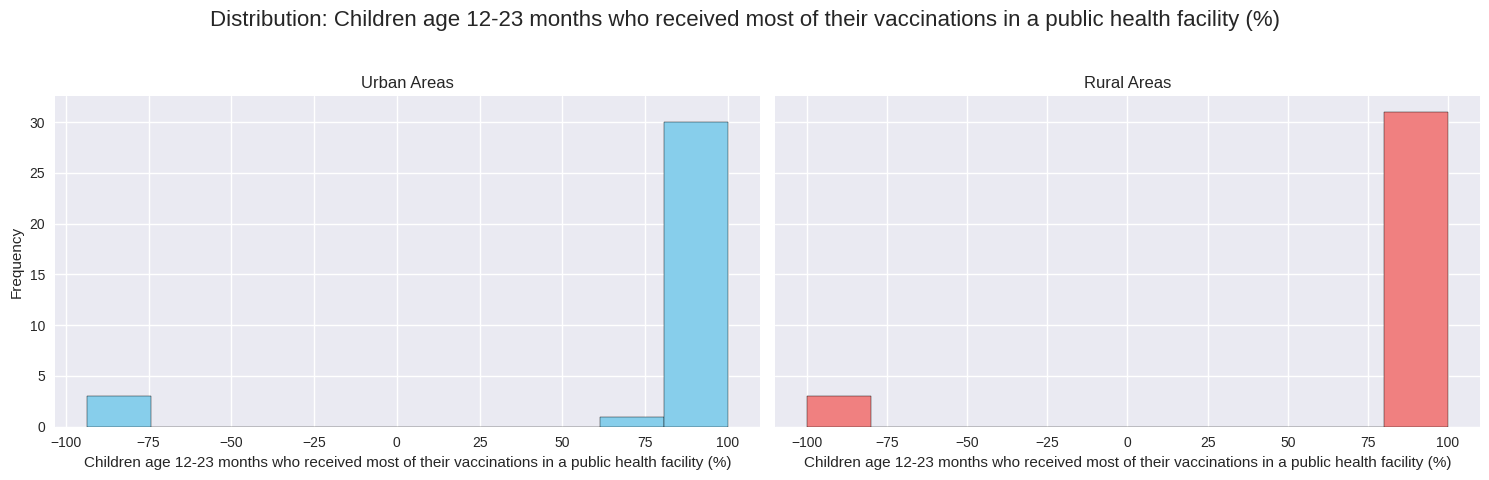

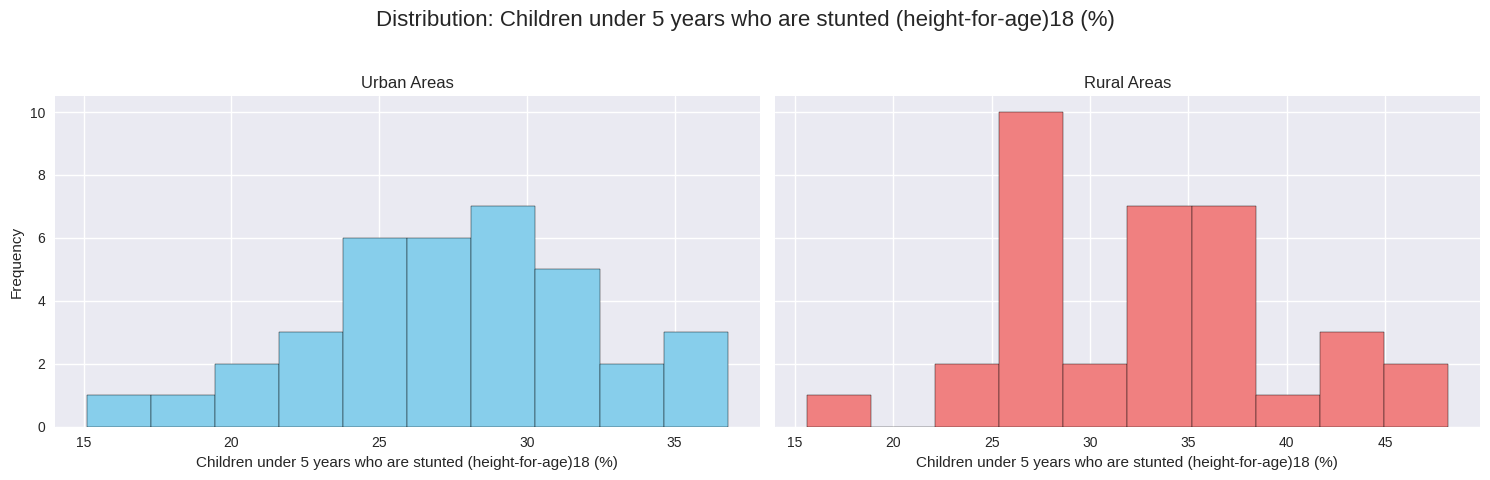

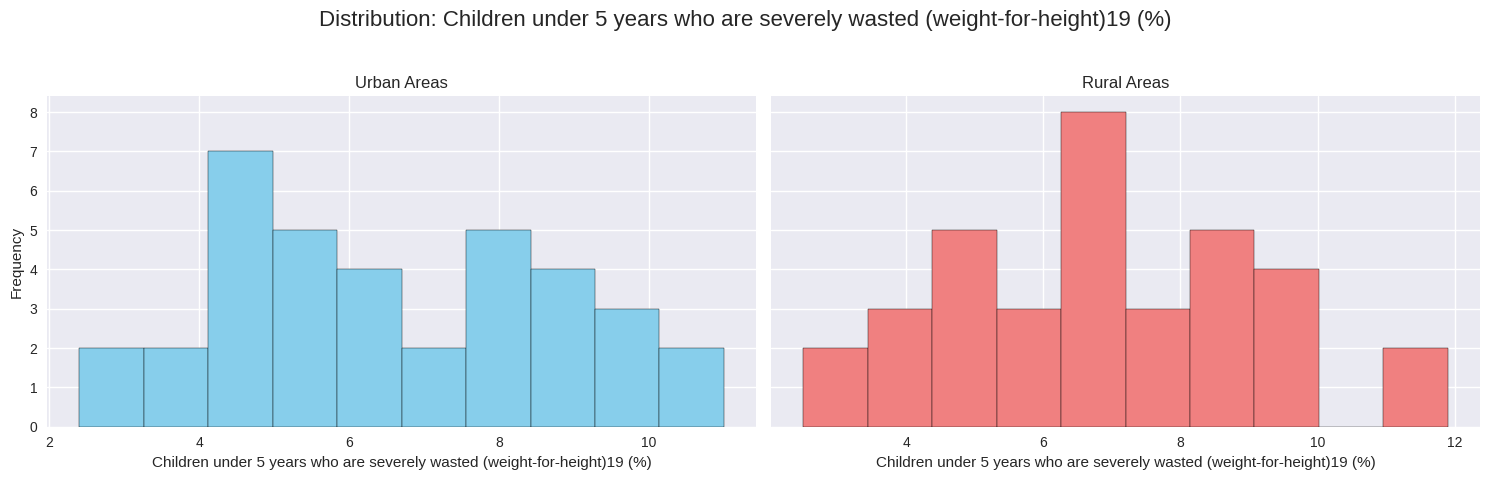

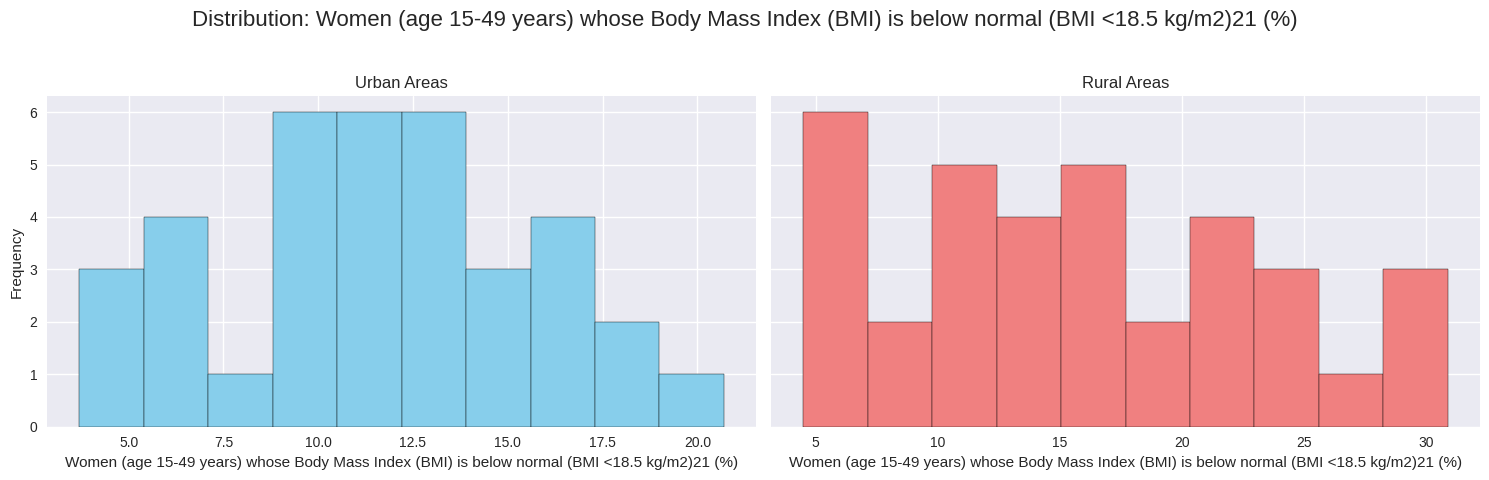

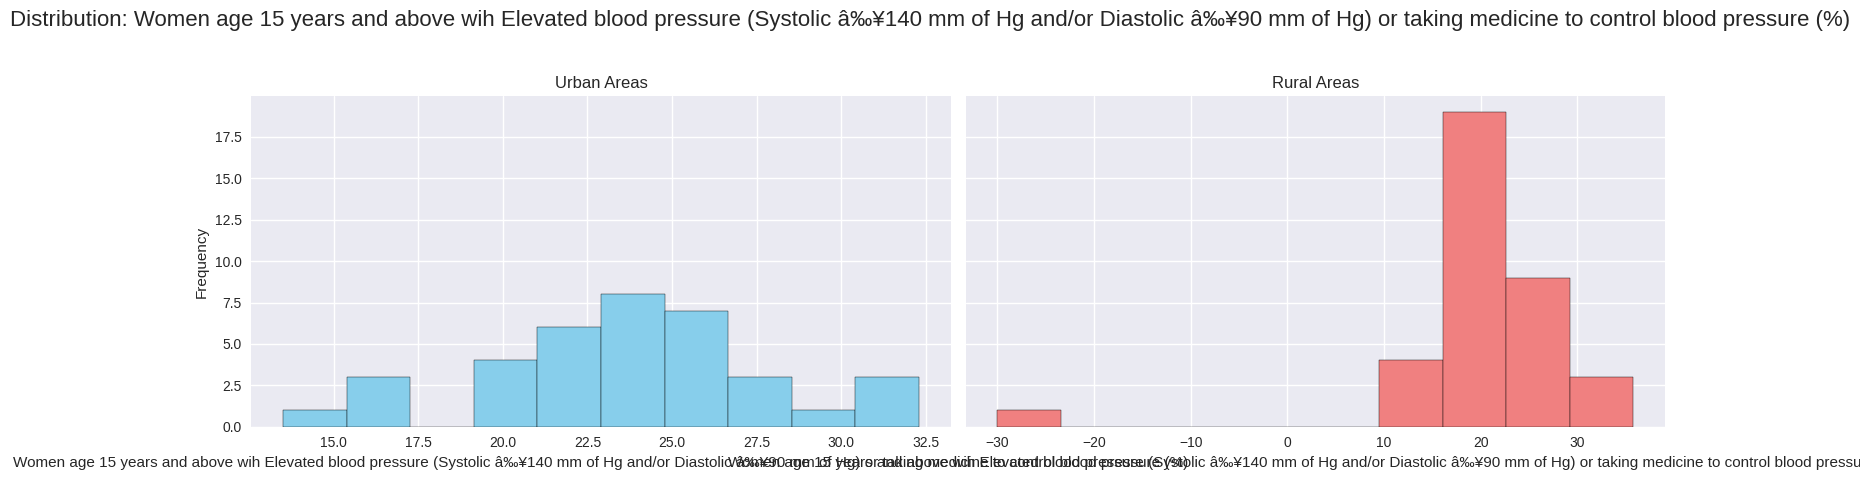

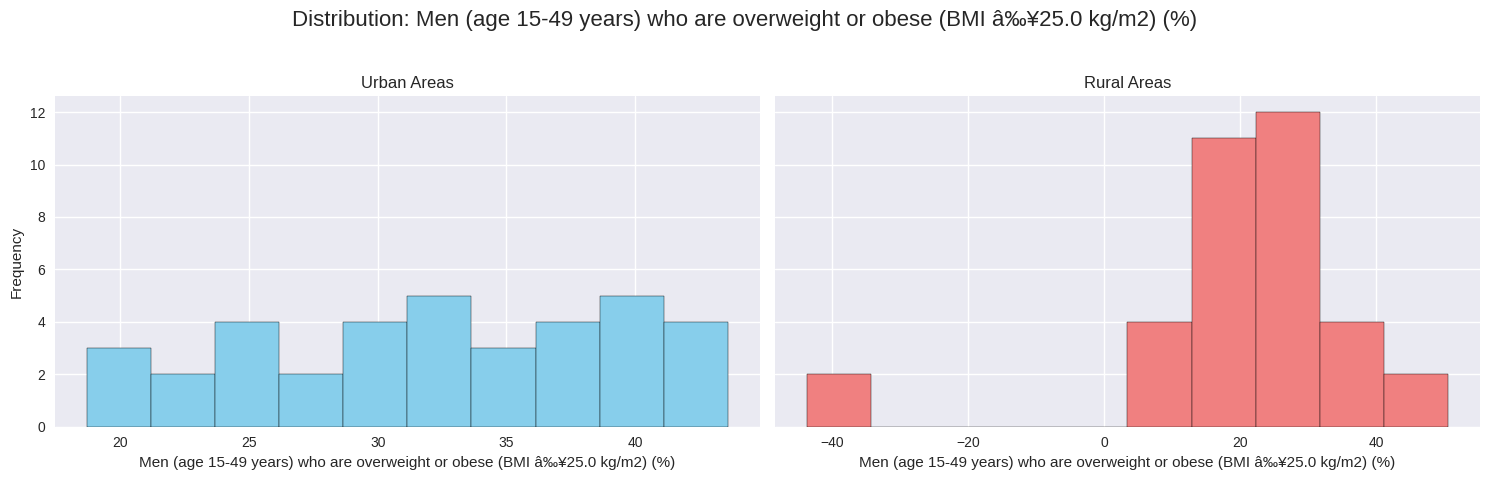

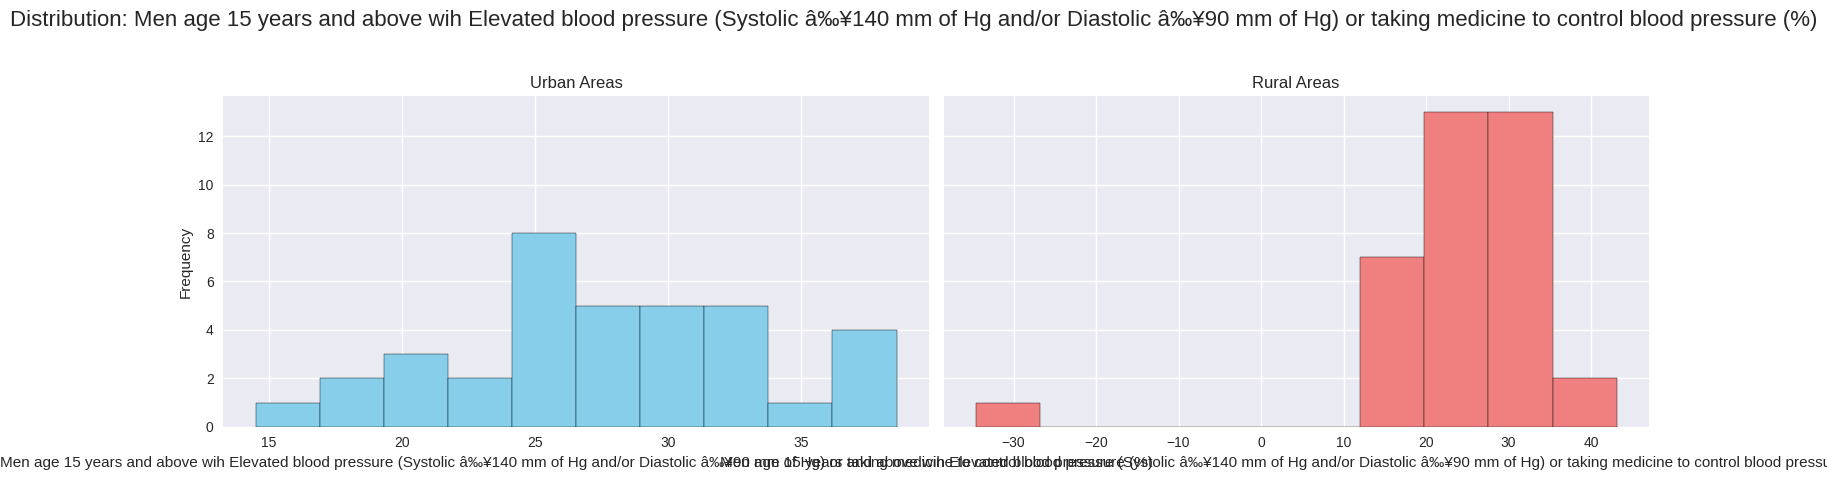

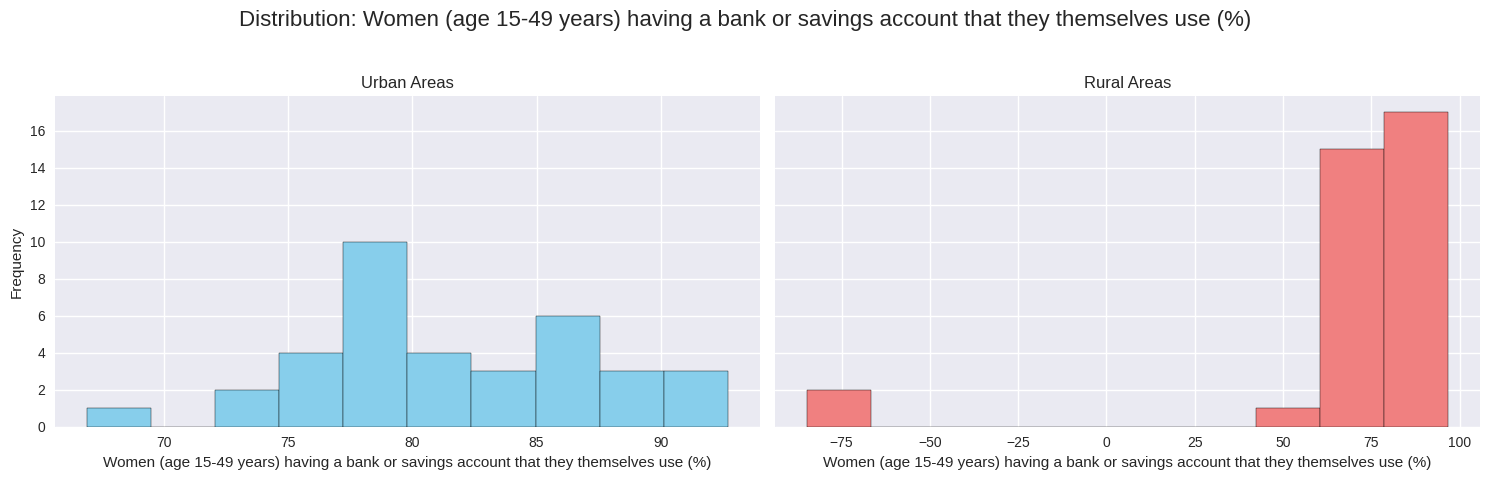

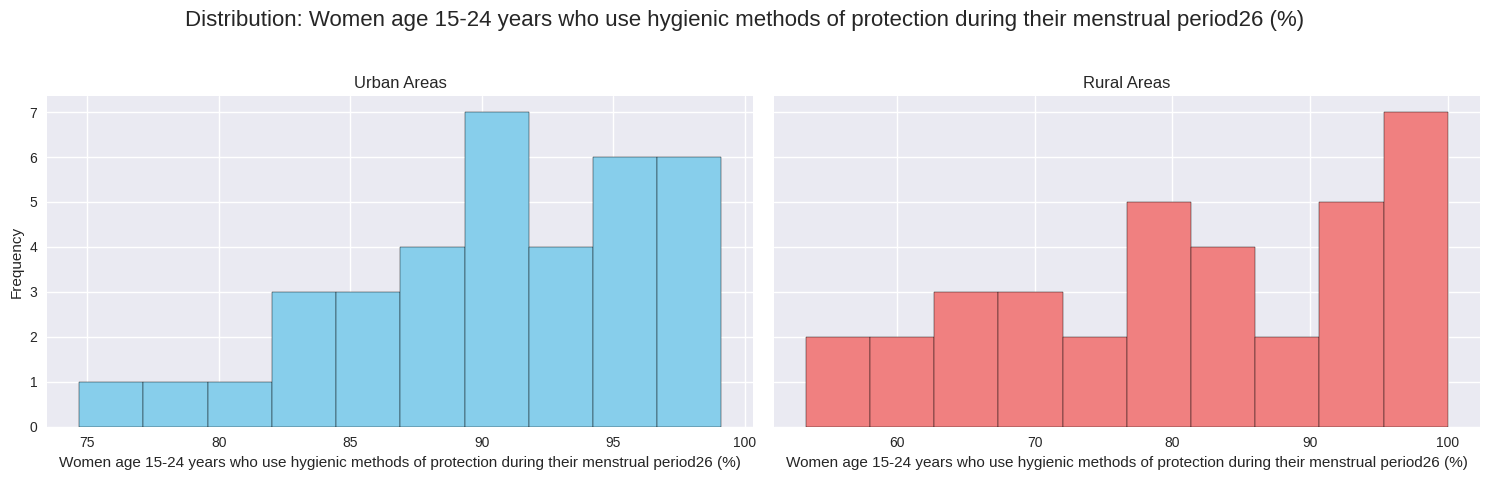

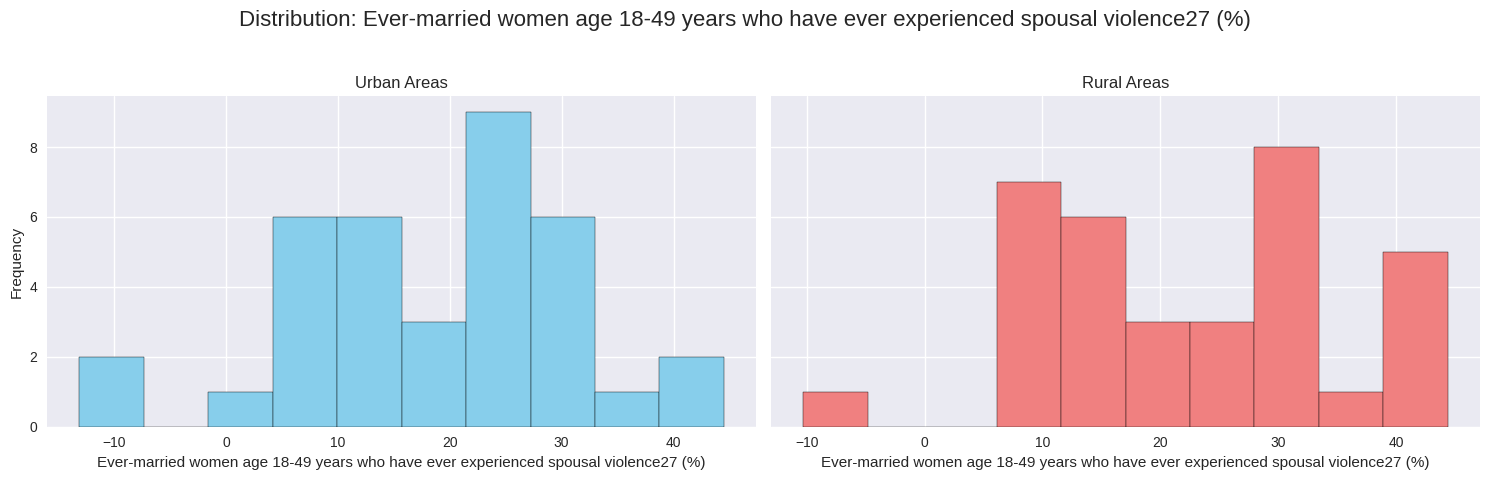

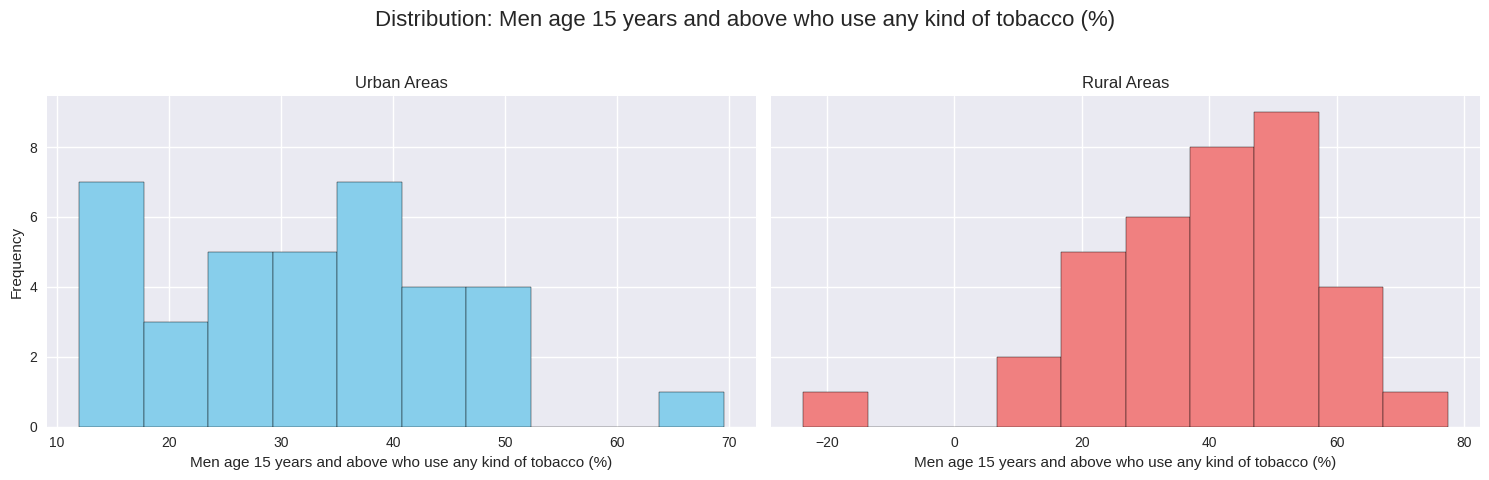

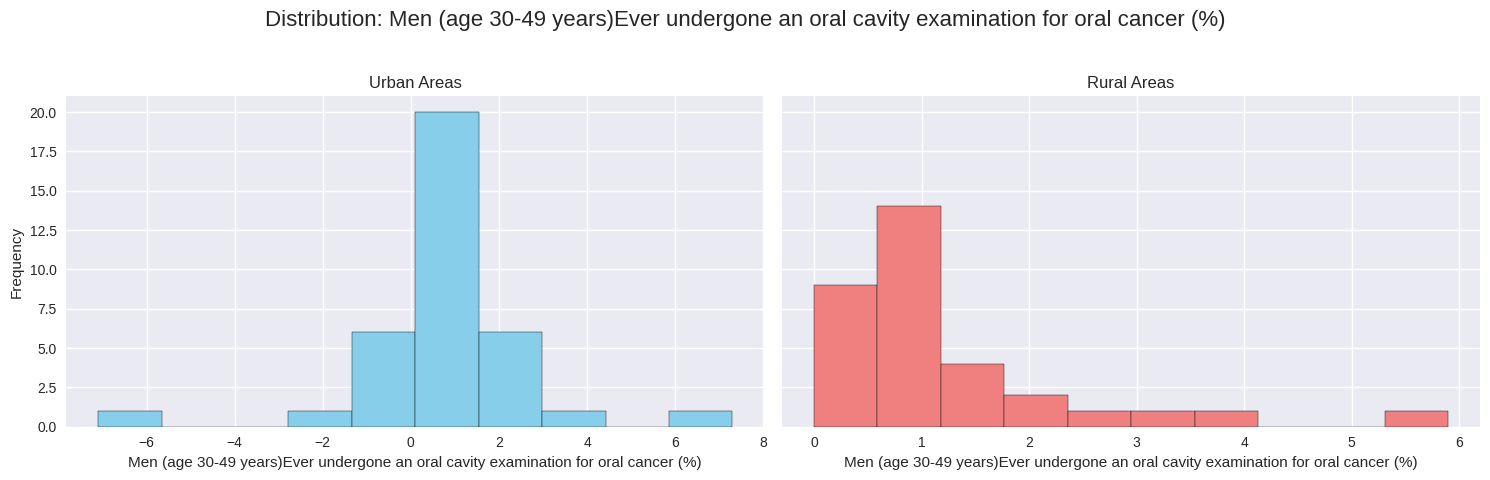

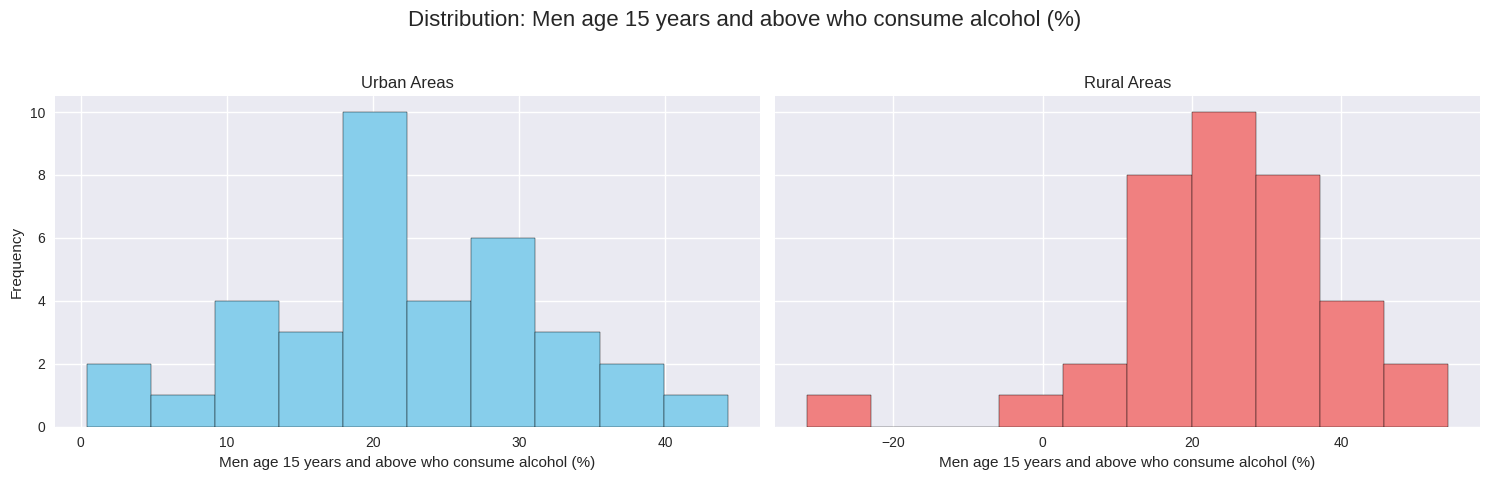

In [ ]:
# Filter out the first three rows which represent 'India' totals (Urban, Rural, Total)
df_filtered = df.iloc[3:].copy()

# Filter out 'Total' rows for individual States/UTs, keeping only 'Urban' and 'Rural'
df_filtered = df_filtered[df_filtered['Area'] != 'Total'].copy()
df_total = df[df['Area'] == 'Total'].copy()

# Define the numeric columns that need to be processed. This list must contain all columns
# that will be used for plotting and numeric conversion.
numeric_cols = [
    "Population below age 15 years (%)",
    " Sex ratio of the total population (females per 1,000 males)",
    "Sex ratio at birth for children born in the last five years (females per 1,000 males)",
    "Households using iodized salt (%)",
    "Women (age 15-49) who are literate4 (%)",
    "Men (age 15-49) who are literate4 (%)",
    "Women (age 15-49)  with 10 or more years of schooling (%)",
    "Men (age 15-49)  with 10 or more years of schooling (%)",
    "Women (age 15-49)  who have ever used the internet (%)",
    "Men (age 15-49)  who have ever used the internet (%)",
    "Women age 20-24 years married before age 18 years (%)",
    "Total Fertility Rate (number of children per woman)",
    "Infant mortality rate (per 1000 live births)",
    "Neonatal mortality rate (per 1000 live births)",
    "Current Use of Family Planning Methods (Currently Married Women Age 15-49  years) - Any method6 (%)",
    "Current Use of Family Planning Methods (Currently Married Women Age 15-49  years) - Any modern method6 (%)",
    "Institutional births (in the 5 years before the survey) (%)",
    "Mothers who consumed iron folic acid for 100 days or more when they were pregnant (for last birth in the 5 years before the survey) (%)",
    "Children age 12-23 months who received most of their vaccinations in a public health facility (%)",
    "Children under 5 years who are stunted (height-for-age)18 (%)",
    "Children under 5 years who are severely wasted (weight-for-height)19 (%)",
    "Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)",
    "All women age 15-49 years who are anaemic22 (%)"
    "Women (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2)21 (%)",
    "Women age 15 years and above wih Elevated blood pressure (Systolic â‰¥140 mm of Hg and/or Diastolic â‰¥90 mm of Hg) or taking medicine to control blood pressure (%)",
    "Men (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2) (%)",
    "Men age 15 years and above wih Elevated blood pressure (Systolic â‰¥140 mm of Hg and/or Diastolic â‰¥90 mm of Hg) or taking medicine to control blood pressure (%)",
    "Women (age 15-49 years) having a bank or savings account that they themselves use (%)",
    "Women age 15-24 years who use hygienic methods of protection during their menstrual period26 (%)",
    "Ever-married women age 18-49 years who have ever experienced spousal violence27 (%)",
    "Men age 15 years and above who use any kind of tobacco (%)",
    "Men (age 30-49 years)Ever undergone an oral cavity examination for oral cancer (%)",
    "Men age 15 years and above who consume alcohol (%)"
]

# Select relevant columns, including 'Area' for filtering and all numeric_cols
cols = [
    "States/UTs",
    "Area" # Include 'Area' column for urban/rural distinction
] + numeric_cols # Append all numeric columns to the selection list

# Ensure only existing columns are selected to prevent KeyError if some are missing in the original df
existing_cols = [col for col in cols if col in df_filtered.columns]
demo_df = df_filtered[existing_cols].copy()

# Convert numeric columns to numeric type, replacing '*' with NaN
# Filter numeric_cols to only include those actually present in demo_df after selection
actual_numeric_cols = [col for col in numeric_cols if col in demo_df.columns]
for col in actual_numeric_cols:
    demo_df[col] = pd.to_numeric(demo_df[col], errors='coerce')

# Also convert numeric columns in df_total
actual_numeric_cols_total = [col for col in numeric_cols if col in df_total.columns]
for col in actual_numeric_cols_total:
    df_total[col] = pd.to_numeric(df_total[col], errors='coerce')

# Display basic info of the processed dataframe
print("Basic info of processed data:")
df_info = demo_df.info()

# Summary statistics of the processed dataframe
print("\nSummary statistics of processed data:")
summary_stats = demo_df.describe()
print(summary_stats)

# Check missing values in the processed dataframe
print("\nMissing values in processed data:")
missing_values = demo_df.isna().sum()
print(missing_values)

# Split data into urban and rural datasets
urban_df = demo_df[demo_df['Area'] == 'Urban'].copy()
rural_df = demo_df[demo_df['Area'] == 'Rural'].copy()

# Generate side-by-side histograms for each demographic indicator
for indicator in actual_numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True) # Share y-axis for consistent comparison
    fig.suptitle(f'Distribution: {indicator}', fontsize=16)

    # Urban Plot
    axes[0].hist(urban_df[indicator].dropna(), bins=10, edgecolor='black', color='skyblue')
    axes[0].set_title('Urban Areas')
    axes[0].set_xlabel(indicator)
    axes[0].set_ylabel('Frequency')

    # Rural Plot
    axes[1].hist(rural_df[indicator].dropna(), bins=10, edgecolor='black', color='lightcoral')
    axes[1].set_title('Rural Areas')
    axes[1].set_xlabel(indicator)
    # axes[1].set_ylabel('Frequency') # Y-axis is shared

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle from overlapping
    plt.show()

In [ ]:
outcomes = {
    "IMR": "Infant mortality rate (per 1000 live births)",
    "Neonatal Mortality": "Neonatal mortality rate (per 1000 live births)",
    "Stunting": "Children under 5 years who are stunted (height-for-age)18 (%)",
    "Severe Wasting": "Children under 5 years who are severely wasted (weight-for-height)19 (%)",
    "Anaemia (Women)": "All women age 15-49 years who are anaemic22 (%)",
    "Low BMI (Women)": "Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)",
    "Overweight (Women)": "Women (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2)21 (%)"
}

exposures = {
    "Female Literacy": "Women (age 15-49) who are literate4 (%)",
    "Male Literacy": "Men (age 15-49) who are literate4 (%)",
    "Early Marriage": "Women age 20-24 years married before age 18 years (%)",
    "Iodized Salt": "Households using iodized salt (%)",
    "Family Planning": "Current Use of Family Planning Methods (Currently Married Women Age 15-49  years) - Any modern method6 (%)",
    "Bank Account (Women)": "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"
}


In [ ]:
from scipy.stats import spearmanr

def classify_pattern(x, y):
    """
    Classifies relationship based on Spearman correlation
    """
    valid = ~(x.isna() | y.isna())
    x, y = x[valid], y[valid]

    if len(x) < 10:
        return "Insufficient data"

    rho, p = spearmanr(x, y)

    if p > 0.1:
        return "No clear association"
    elif rho <= -0.6:
        return "Strong negative gradient"
    elif -0.6 < rho <= -0.3:
        return "Moderate negative association"
    elif 0.3 <= rho < 0.6:
        return "Moderate positive association"
    elif rho >= 0.6:
        return "Strong positive gradient"
    else:
        return "Weak / nonlinear pattern"


In [ ]:
results = []

for out_name, out_col in outcomes.items():
    for exp_name, exp_col in exposures.items():
        # Check if both outcome and exposure columns are in the cleaned numeric dataframe
        if out_col in actual_numeric_cols and exp_col in actual_numeric_cols:
            pattern = classify_pattern(demo_df[exp_col], demo_df[out_col])
            results.append({
                "Outcome": out_name,
                "Exposure": exp_name,
                "Pattern Observed": pattern
            })

print("Correlation analysis results:")
for res in results:
    print(res)


Correlation analysis results:
{'Outcome': 'IMR', 'Exposure': 'Female Literacy', 'Pattern Observed': 'Moderate negative association'}
{'Outcome': 'IMR', 'Exposure': 'Male Literacy', 'Pattern Observed': 'Moderate negative association'}
{'Outcome': 'IMR', 'Exposure': 'Early Marriage', 'Pattern Observed': 'Moderate positive association'}
{'Outcome': 'IMR', 'Exposure': 'Iodized Salt', 'Pattern Observed': 'Moderate negative association'}
{'Outcome': 'IMR', 'Exposure': 'Family Planning', 'Pattern Observed': 'No clear association'}
{'Outcome': 'IMR', 'Exposure': 'Bank Account (Women)', 'Pattern Observed': 'Weak / nonlinear pattern'}
{'Outcome': 'Neonatal Mortality', 'Exposure': 'Female Literacy', 'Pattern Observed': 'Moderate negative association'}
{'Outcome': 'Neonatal Mortality', 'Exposure': 'Male Literacy', 'Pattern Observed': 'Moderate negative association'}
{'Outcome': 'Neonatal Mortality', 'Exposure': 'Early Marriage', 'Pattern Observed': 'Moderate positive association'}
{'Outcome': 'Neo

In [ ]:
pairwise_table = pd.DataFrame(results)
pairwise_table.head(10)


,Outcome,Exposure,Pattern Observed
0,IMR,Female Literacy,Moderate negative association
1,IMR,Male Literacy,Moderate negative association
2,IMR,Early Marriage,Moderate positive association
3,IMR,Iodized Salt,Moderate negative association
4,IMR,Family Planning,No clear association
5,IMR,Bank Account (Women),Weak / nonlinear pattern
6,Neonatal Mortality,Female Literacy,Moderate negative association
7,Neonatal Mortality,Male Literacy,Moderate negative association
8,Neonatal Mortality,Early Marriage,Moderate positive association
9,Neonatal Mortality,Iodized Salt,Moderate negative association


In [ ]:
pairwise_table[
    pairwise_table["Pattern Observed"].isin([
        "Strong negative gradient",
        "Moderate negative association",
        "Strong positive gradient",
        "Moderate positive association"
    ])
].sort_values(["Outcome", "Pattern Observed"])


,Outcome,Exposure,Pattern Observed
0,IMR,Female Literacy,Moderate negative association
1,IMR,Male Literacy,Moderate negative association
3,IMR,Iodized Salt,Moderate negative association
2,IMR,Early Marriage,Moderate positive association
24,Low BMI (Women),Female Literacy,Moderate negative association
25,Low BMI (Women),Male Literacy,Moderate negative association
27,Low BMI (Women),Iodized Salt,Moderate negative association
28,Low BMI (Women),Family Planning,Moderate positive association
26,Low BMI (Women),Early Marriage,Strong positive gradient
6,Neonatal Mortality,Female Literacy,Moderate negative association


In [ ]:
outcome_pairs = [
    ("Infant mortality rate (per 1000 live births)",
     "Children age 12-23 months who received most of their vaccinations in a public health facility (%)"),

    ("Children under 5 years who are stunted (height-for-age)18 (%)",
     "Children under 5 years who are severely wasted (weight-for-height)19 (%)"),

    ("All women age 15-49 years who are anaemic22 (%)",
     "Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)"),

    ("Women (age 15-49 years) who are overweight or obese (BMI â‰¥25.0 kg/m2)21 (%)",
     "Women age 15 years and above wih Elevated blood pressure (Systolic â‰¥140 mm of Hg and/or Diastolic â‰¥90 mm of Hg) or taking medicine to control blood pressure (%)"),

    ("Infant mortality rate (per 1000 live births)",
     "Children under 5 years who are stunted (height-for-age)18 (%)"),

    ("Women (age 15-49) who are literate4 (%)",
     "Children under 5 years who are stunted (height-for-age)18 (%)")
]

In [ ]:
exposure_pairs = [
    ("Women (age 15-49) who are literate4 (%)",
    "Women (age 15-49 years) having a bank or savings account that they themselves use (%)"),

    ("Women (age 15-49) who are literate4 (%)",
     "Women (age 15-49)  who have ever used the internet (%)"),

    ("Women age 20-24 years married before age 18 years (%)",
     "Total Fertility Rate (number of children per woman)"),

    ("Institutional births (in the 5 years before the survey) (%)",
     "Women (age 15-49) who are literate4 (%)"),

    ("Women (age 15-49 years) having a bank or savings account that they themselves use (%)",
    "Women (age 15-49) who are literate4 (%)")
]


In [ ]:
outcome_results = []

for y1, y2 in outcome_pairs:
    # Check if both outcome and exposure columns are in the cleaned numeric dataframe (df_total in this case)
    if y1 in df_total.columns and y2 in df_total.columns:
        pattern = classify_pattern(df_total[y1], df_total[y2])
        outcome_results.append({
            "Variable 1": y1,
            "Variable 2": y2,
            "Type": "Outcome–Outcome",
            "Pattern Observed": pattern
        })

outcome_outcome_df = pd.DataFrame(outcome_results)
outcome_outcome_df

,Variable 1,Variable 2,Type,Pattern Observed
0,Infant mortality rate (per 1000 live births),Children age 12-23 months who received most of...,Outcome–Outcome,No clear association
1,Children under 5 years who are stunted (height...,Children under 5 years who are severely wasted...,Outcome–Outcome,Moderate positive association
2,All women age 15-49 years who are anaemic22 (%),Women (age 15-49 years) whose Body Mass Index ...,Outcome–Outcome,Moderate positive association
3,Women (age 15-49 years) who are overweight or ...,Women age 15 years and above wih Elevated bloo...,Outcome–Outcome,Strong positive gradient
4,Infant mortality rate (per 1000 live births),Children under 5 years who are stunted (height...,Outcome–Outcome,Strong positive gradient
5,Women (age 15-49) who are literate4 (%),Children under 5 years who are stunted (height...,Outcome–Outcome,Moderate negative association


In [ ]:
exposure_results = []

for x1, x2 in exposure_pairs:
    # Check if both exposure columns are in the cleaned numeric dataframe
    if x1 in df_total.columns and x2 in df_total.columns:
        pattern = classify_pattern(df_total[x1], df_total[x2])
        exposure_results.append({
            "Variable 1": x1,
            "Variable 2": x2,
            "Type": "Exposure–Exposure",
            "Pattern Observed": pattern
        })

exposure_exposure_df = pd.DataFrame(exposure_results)
exposure_exposure_df

,Variable 1,Variable 2,Type,Pattern Observed
0,Women (age 15-49) who are literate4 (%),Women (age 15-49 years) having a bank or savin...,Exposure–Exposure,No clear association
1,Women (age 15-49) who are literate4 (%),Women (age 15-49) who have ever used the inte...,Exposure–Exposure,Strong positive gradient
2,Women age 20-24 years married before age 18 ye...,Total Fertility Rate (number of children per w...,Exposure–Exposure,Moderate positive association
3,Institutional births (in the 5 years before th...,Women (age 15-49) who are literate4 (%),Exposure–Exposure,Weak / nonlinear pattern
4,Women (age 15-49 years) having a bank or savin...,Women (age 15-49) who are literate4 (%),Exposure–Exposure,No clear association


In [ ]:
pairwise_internal_df = pd.concat(
    [outcome_outcome_df, exposure_exposure_df],
    ignore_index=True
)

pairwise_internal_df

,Variable 1,Variable 2,Type,Pattern Observed
0,Infant mortality rate (per 1000 live births),Children age 12-23 months who received most of...,Outcome–Outcome,No clear association
1,Children under 5 years who are stunted (height...,Children under 5 years who are severely wasted...,Outcome–Outcome,Moderate positive association
2,All women age 15-49 years who are anaemic22 (%),Women (age 15-49 years) whose Body Mass Index ...,Outcome–Outcome,Moderate positive association
3,Women (age 15-49 years) who are overweight or ...,Women age 15 years and above wih Elevated bloo...,Outcome–Outcome,Strong positive gradient
4,Infant mortality rate (per 1000 live births),Children under 5 years who are stunted (height...,Outcome–Outcome,Strong positive gradient
5,Women (age 15-49) who are literate4 (%),Children under 5 years who are stunted (height...,Outcome–Outcome,Moderate negative association
6,Women (age 15-49) who are literate4 (%),Women (age 15-49 years) having a bank or savin...,Exposure–Exposure,No clear association
7,Women (age 15-49) who are literate4 (%),Women (age 15-49) who have ever used the inte...,Exposure–Exposure,Strong positive gradient
8,Women age 20-24 years married before age 18 ye...,Total Fertility Rate (number of children per w...,Exposure–Exposure,Moderate positive association
9,Institutional births (in the 5 years before th...,Women (age 15-49) who are literate4 (%),Exposure–Exposure,Weak / nonlinear pattern


In [ ]:
corr_matrix = demo_df[actual_numeric_cols].corr(method="pearson")

In [ ]:
import numpy as np

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Indicator_1", "Indicator_2", "Correlation"]


In [ ]:
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

ranked_pairs = corr_pairs.sort_values(
    by="Abs_Correlation",
    ascending=False
).reset_index(drop=True)


In [ ]:
ranked_pairs.head(20)


,Indicator_1,Indicator_2,Correlation,Abs_Correlation
0,Women age 15 years and above wih Elevated bloo...,Men age 15 years and above wih Elevated blood ...,0.949083,0.949083
1,Population below age 15 years (%),Total Fertility Rate (number of children per w...,0.853073,0.853073
2,Men (age 15-49 years) who are overweight or ob...,Women (age 15-49 years) having a bank or savin...,0.833445,0.833445
3,Men (age 15-49) who are literate4 (%),Men (age 15-49) with 10 or more years of scho...,0.819755,0.819755
4,Men (age 15-49) with 10 or more years of scho...,Women (age 15-49) who have ever used the inte...,0.798572,0.798572
5,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of sc...,0.790418,0.790418
6,Infant mortality rate (per 1000 live births),Neonatal mortality rate (per 1000 live births),0.760562,0.760562
7,Women (age 15-49) with 10 or more years of sc...,Women age 20-24 years married before age 18 ye...,-0.742845,0.742845
8,Women (age 15-49) with 10 or more years of sc...,Women age 15-24 years who use hygienic methods...,0.739134,0.739134
9,Current Use of Family Planning Methods (Curren...,Current Use of Family Planning Methods (Curren...,0.732420,0.732420


In [ ]:
corr_matrix = demo_df[actual_numeric_cols].corr(method="spearman")


In [ ]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Indicator_1", "Indicator_2", "Correlation"]


In [ ]:
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

ranked_pairs = corr_pairs.sort_values(
    by="Abs_Correlation",
    ascending=False
).reset_index(drop=True)

In [ ]:
ranked_pairs.head(30)


,Indicator_1,Indicator_2,Correlation,Abs_Correlation
0,Infant mortality rate (per 1000 live births),Neonatal mortality rate (per 1000 live births),0.875783,0.875783
1,Women age 15 years and above wih Elevated bloo...,Men age 15 years and above wih Elevated blood ...,0.854416,0.854416
2,Women (age 15-49) with 10 or more years of sc...,Men (age 15-49) with 10 or more years of scho...,0.849526,0.849526
3,Women (age 15-49) who have ever used the inte...,Men (age 15-49) who have ever used the intern...,0.799879,0.799879
4,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of sc...,0.780314,0.780314
5,Women (age 15-49) with 10 or more years of sc...,Men (age 15-49) who have ever used the intern...,0.778427,0.778427
6,Men (age 15-49) with 10 or more years of scho...,Women (age 15-49) who have ever used the inte...,0.774752,0.774752
7,Women (age 15-49) with 10 or more years of sc...,Women (age 15-49) who have ever used the inte...,0.769956,0.769956
8,Population below age 15 years (%),Total Fertility Rate (number of children per w...,0.760360,0.760360
9,Women (age 15-49) who are literate4 (%),Men (age 15-49) who are literate4 (%),0.729778,0.729778


In [ ]:
corr_matrix = demo_df[actual_numeric_cols].corr(method="kendall")


In [ ]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Indicator_1", "Indicator_2", "Correlation"]


In [ ]:
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

ranked_pairs = corr_pairs.sort_values(
    by="Abs_Correlation",
    ascending=False
).reset_index(drop=True)

In [ ]:
ranked_pairs.head(30)

,Indicator_1,Indicator_2,Correlation,Abs_Correlation
0,Infant mortality rate (per 1000 live births),Neonatal mortality rate (per 1000 live births),0.766355,0.766355
1,Women (age 15-49) with 10 or more years of sc...,Men (age 15-49) with 10 or more years of scho...,0.706855,0.706855
2,Women age 15 years and above wih Elevated bloo...,Men age 15 years and above wih Elevated blood ...,0.685806,0.685806
3,Women (age 15-49) who have ever used the inte...,Men (age 15-49) who have ever used the intern...,0.659279,0.659279
4,Population below age 15 years (%),Total Fertility Rate (number of children per w...,0.608507,0.608507
5,Women (age 15-49) with 10 or more years of sc...,Women (age 15-49) who have ever used the inte...,0.602055,0.602055
6,Women (age 15-49) who are literate4 (%),Women (age 15-49) with 10 or more years of sc...,0.591925,0.591925
7,Men (age 15-49) with 10 or more years of scho...,Women (age 15-49) who have ever used the inte...,0.581906,0.581906
8,Women (age 15-49) with 10 or more years of sc...,Men (age 15-49) who have ever used the intern...,0.572984,0.572984
9,Women (age 15-49) who are literate4 (%),Men (age 15-49) who are literate4 (%),0.565719,0.565719
